<table style="background-color: transparent;">
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%" align="center"><font size="7" color="#6366F1">Computación Cuántica</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Temas Selectos de Ingeniería en Computación III</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">2027-1</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="6" color="#6366F1">Laboratorio 2: Sistemas Multi Qubits</font></td>
    </tr>
</table>

---
<h3>Autores:</h3>

<h4>
- Naomi Reyes Granados<br>
- Sebastián González Juárez<br>
- Owen Charbel Sam Ramírez <br>
- Angel Carmona Zavaleta
</h4>

<p>
Este notebook está adaptado del material desarrollado originalmente por
<b>Claudia Zendejas Morales</b>, el cual constituye la base principal de este
notebook. Sobre dicho material se realizaron modificaciones, ampliaciones y
adaptaciones para su uso en esta clase.
</p>

---

$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\mymatrix}[2]{\left[ \begin{array}{#1} #2\end{array} \right]} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $

## Contenido

1. [Sistemas con más de un Qubit](#1)
   1. [Estados multi-qubit](#1.1)
   2. [Compuertas de un qubit en estados multi-qubit](#1.2)
   3. [Compuertas de dos qubits](#1.3)
      1. [Compuerta $CNOT$ o $CX$](#1.3.1)
      2. [Compuertas controladas](#1.3.2)
      3. [Compuerta $SWAP$](#1.3.3)
   4. [Compuertas de más qubits](#1.4)
      1. [Compuerta Toffoli , $CCNOT$ o $CCX$](#1.4.1)
      2. [Compuerta Fredkin o $CSWAP$](#1.4.2)
      3. [Compuerta controlada personaliza](#1.4.3)
2. [Estados de Bell: Entrelazamiento](#2)
3. [QSphere, otra forma de visualizar estados multi-qubit](#3)
4. [Simular Circuitos Cuánticos](#4)
      1. [Primitivas de Qiskit Runtime](#4.1)
          1. [Primitiva Sampler](#4.1.1)
          2. [Primitiva Estimator](#4.1.2)
5. [Errores y cómo corregirlos](#5)
   1. [Mitigación de errores](#5.1)
   2. [Corrección de errores](#5.2)
   3. [Diferencias](#5.3)
6. [Ejemplos en las SpinQ](#6)
   1. [Simulación con SpinQit](#6.1)
   2. [Ejecución en las SpinQ](#6.2)
7. [Práctica 2](#7)

In [ ]:
# Instalación de Qiskit
%pip install qiskit

In [ ]:
%pip install -U pylatexenc

<a id="1"></a>
## 1. Sistemas con más de un Qubit

Hemos visto algunos efectos interesantes con qubits individuales y compuertas de un qubit, pero el verdadero poder de la computación cuántica se realiza a través de las interacciones entre qubits. En este notebook, presentaremos compuertas de múltiples qubits y exploraremos comportamientos interesantes de los sistemas multi-qubit.

Por lo general, las compuertas que se pueden implementar directamente en el hardware actuarán solo en uno o dos qubits. En nuestros circuitos, podemos querer usar compuertas complejas que actúen sobre una gran cantidad de qubits. Afortunadamente, esto no será un problema. Con las compuertas de uno y dos qubits que nos proporciona el hardware, es posible construir cualquier otra compuerta.

<a id="1.1"></a>
## 1.1. Estados multi-qubit

La dimensión del espacio de Hilbert para $n$ qubits está dado por $2^n$. Para obtenerlo se usa el **producto tensorial** (o *[producto de Kronecker](https://en.wikipedia.org/wiki/Kronecker_product)*).

### Recordatorio: Producto tensorial

El producto tensorial, denotado por $\otimes$, se puede aplicar a vectores y matrices (en general a [tensores](https://en.wikipedia.org/wiki/Tensor)). Actúa como sigue,

$$\vec{a}\otimes\vec{b}=\mymatrix{r}{ a_1 \\ a_2 }\otimes\mymatrix{r}{ b_1 \\ b_2 }=\mymatrix{r}{ a_1\mymatrix{r}{ b_1 \\ b_2 } \\ a_2\mymatrix{r}{ b_1 \\ b_2 } }=\mymatrix{r}{ a_1b_1 \\ a_1b_2 \\ a_2b_1 \\ a_2b_2 }$$

$$C\otimes D=\mymatrix{r}{ c_{11} & c_{12} \\ c_{21} & c_{22} }\otimes\mymatrix{r}{ d_{11} & d_{12} \\ d_{21} & d_{22} }=\mymatrix{r}{ c_{11}\mymatrix{r}{ d_{11} & d_{12} \\ d_{21} & d_{22} } & c_{12}\mymatrix{r}{ d_{11} & d_{12} \\ d_{21} & d_{22} } \\ c_{21}\mymatrix{r}{ d_{11} & d_{12} \\ d_{21} & d_{22} } & c_{22}\mymatrix{r}{ d_{11} & d_{12} \\ d_{21} & d_{22} } }=\mymatrix{r}{ c_{11}d_{11} & c_{11}d_{12} & c_{12}d_{11} & c_{12}d_{12} \\ c_{11}d_{21} & c_{11}d_{22} & c_{12}d_{21} & c_{12}d_{22} \\ c_{21}d_{11} & c_{21}d_{12} & c_{22}d_{11} & c_{22}d_{12} \\ c_{21}d_{21} & c_{21}d_{22} & c_{22}d_{21} & c_{22}d_{22}}$$

### El espacio de 2 qubits

El espacio de Hilbert de un estado cuántico formado por dos qubits, $n=2$, tendrá una dimensión de $2^2=4$. Por ejemplo, el estado formado por dos qubits, cada uno en $\ket{0}$ es,

$$\ket{0}\otimes\ket{0}=\ket{00}=\mymatrix{r}{ 1 \\ 0 }\otimes\mymatrix{r}{ 1 \\ 0 }=\mymatrix{r}{ 1\mymatrix{r}{ 1 \\ 0 } \\ 0\mymatrix{r}{ 1 \\ 0 } }=\mymatrix{r}{ 1 \\ 0 \\ 0 \\ 0 }$$

Ahora, considerando todas las posibles combinaciones de los estados base para cada uno de los dos qubits, tenemos que,

$$\ket{0}\otimes\ket{0}=\ket{00}=\mymatrix{r}{ 1 \\ 0 \\ 0 \\ 0 }$$

$$\ket{0}\otimes\ket{1}=\ket{01}=\mymatrix{r}{ 0 \\ 1 \\ 0 \\ 0 }$$

$$\ket{1}\otimes\ket{0}=\ket{10}=\mymatrix{r}{ 0 \\ 0 \\ 1 \\ 0 }$$

$$\ket{1}\otimes\ket{1}=\ket{11}=\mymatrix{r}{ 0 \\ 0 \\ 0 \\ 1 }$$

Notemos que debido a que estamos usando la *base computacional* para los qubits, podemos tener una relación directa con la representación de los números decimales en binario; es decir, el estado $\ket{00}$ tiene un $1$ en la posición $0$ del vector de estado de cuatro elementos, el estado $\ket{10}$ tienen un $1$ en la posición $2$ (contando desde cero), pues se cumple que $10_{binario} = 2_{decimal}$.


### El espacio de 3 qubits

Para el caso de $n=3$, tenemos que la dimensión es $2^3=8$, entonces los vectores de estado para este espacio de Hilbert, en la base computacional, serían:

$$\ket{000}=\mymatrix{r}{ 1 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 }, ~~~~ \ket{001}=\mymatrix{r}{ 0 \\ 1 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 }, ~~~~ \ket{010}=\mymatrix{r}{ 0 \\ 0 \\ 1 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 }, ~~~~ \ket{011}=\mymatrix{r}{ 0 \\ 0 \\ 0 \\ 1 \\ 0 \\ 0 \\ 0 \\ 0 }$$

$$\ket{100}=\mymatrix{r}{ 0 \\ 0 \\ 0 \\ 0 \\ 1 \\ 0 \\ 0 \\ 0 }, ~~~~ \ket{101}=\mymatrix{r}{ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 1 \\ 0 \\ 0 }, ~~~~ \ket{110}=\mymatrix{r}{ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 1 \\ 0 }, ~~~~ \ket{111}=\mymatrix{r}{ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 1 }$$

### Generalización para $n$ qubits


El caso de 3 qubits se puede generalizar fácilmente a cualquier número de qubits. Para un sistema de $n$ qubits, el espacio de Hilbert tiene una dimensión de

$$
\dim(\mathcal{H})=2^n.
$$

Por lo tanto, existen $2^n$ estados en la base computacional, que pueden escribirse como

$$
\ket{q_{n-1}q_{n-2}\cdots q_1q_0},
\qquad q_i\in\{0,1\}.
$$

Por ejemplo, para $n=3$ existen $2^3=8$ estados, mientras que para $n=4$ existen $2^4=16$ estados. En general, cualquier estado multi-qubit puede expresarse como una combinación lineal de estos $2^n$ estados de la base computacional.

$$
\ket{\psi}=
\sum_{i=0}^{2^n-1} \alpha_i\ket{i},
\qquad
\sum_{i=0}^{2^n-1}|\alpha_i|^2=1.
$$

<a id="1.2"></a>
## 1.2. Compuertas de un qubit en estados multi-qubit

Las compuertas de un solo qubit que actúan en estados multi-qubit, deben tener la dimension correcta para poder efectuar la multiplicación matriz por vector.

Si por ejemplo tenemos esto: $H\ket{q_1q_0}$, no se puede saber a cual de los dos qubits se le debe aplicar la compuerta $H$ si a $\ket{q_1}$ o a $\ket{q_0}$, entonces se debe ser explícito. Si lo que se desea es aplicar $H$ al $\ket{q_0}$ se debe escribir:

$$I\otimes H \; \ket{q_1q_0}$$

Lo que implica que se aplicará la compuerta *identidad* al $\ket{q_1}$, es decir, no será afectado.

La compuerta $I\otimes H$ a aplicar al estado de 2 qubits es:

$$I\otimes H=\mymatrix{r}{ 1 & 0 \\ 0 & 1 }\otimes\mymatrix{rr}{\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}}=\mymatrix{r}{ 1\mymatrix{rr}{\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}} & 0\mymatrix{rr}{\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}} \\ 0\mymatrix{rr}{\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}} & 1\mymatrix{rr}{\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}} }=\mymatrix{rrrr}{ \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} & 0 & 0 \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 & 0 \\ 0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ 0 & 0 & \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} }$$

En Qiskit podemos usar la clase `Operator` para obtener el operador equivalente a las compuertas agregadas a un circuito, veamos le ejemplo anterior:

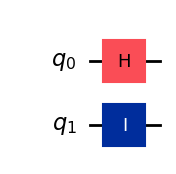

<IPython.core.display.Latex object>

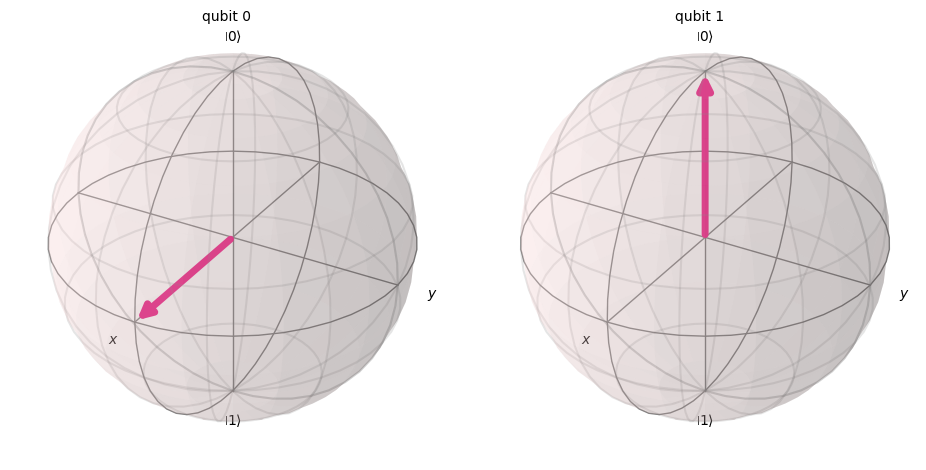

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Operator

circuit = QuantumCircuit(2) # circuito con 2 qubits

circuit.h(0)    # Hadamard en q0
circuit.id(1)   # Identidad en q1

#Desplegamos el circuito.
display(circuit.draw('mpl'))
#Vemos al operador como matriz.
op = Operator(circuit)
display(array_to_latex(op))
#Guardamos al estado final del circuito.
psi = Statevector(circuit)
#Desplegamos al estado represnetado en la esfera de Boch.
display(plot_bloch_multivector(psi))

Ejemplo con $3$ qubits $\ket{q_2 \, q_1 \, q_0}$:

$$H\otimes R_y(3\pi/5) \otimes R_x(\pi/4) \; \ket{000}$$

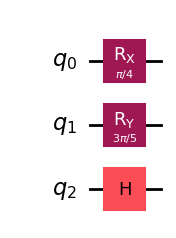

<IPython.core.display.Latex object>

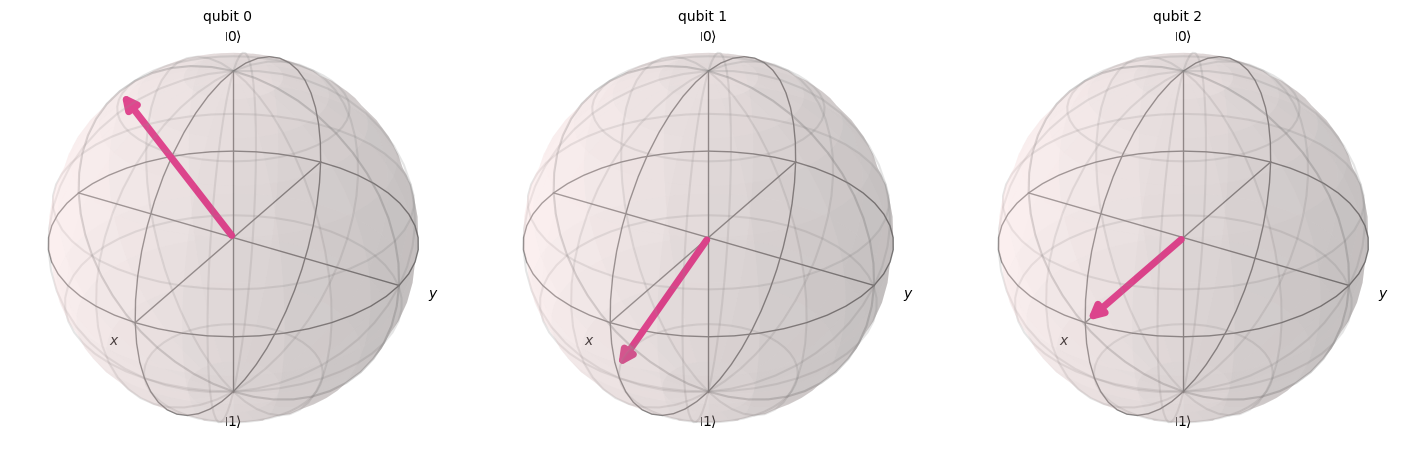

In [ ]:
import numpy as np

circuit = QuantumCircuit(3) # circuito con 3 qubits

circuit.rx(np.pi/4, 0)      # Rx de pi/4  al q0
circuit.ry(3*np.pi/5, 1)    # Ry de 3pi/5 al q1
circuit.h(2)                # Hadamard al q2

display(circuit.draw('mpl'))

op = Operator(circuit)
display(array_to_latex(op))

psi = Statevector(circuit)
display(plot_bloch_multivector(psi))

**Nota**: Si se aplica la misma compuerta a todos los qubits de un estado, se puede indicar con un subíndice, como por ejemplo, la compuerta $H_2=H\otimes H$ es aplicada a dos qubits: $H_2 \, \ket{00}=H\otimes H \, \ket{0}\otimes\ket{0}$ y de la misma manera, se tiene que,

$$H_n \, \underbrace{\ket{0...0}}_{n~qubits}=\underbrace{H\otimes\cdots\otimes H}_{n~Hadamards} \, \underbrace{\ket{0...0}}_{n~qubits}$$

Notaciones usadas:

$$\underbrace{H\otimes\cdots\otimes H}_{n~veces}=\bigotimes_1^n H=H^{\otimes n}=H_n$$

<a id="1.3"></a>
## 1.3. Compuertas de dos qubits

Ahora que ya sabemos cómo son los estados multi-qubit, podemos revisar las compuertas que son aplicadas a más de un qubit. Primero veamos algunas compuertas que necesitan dos qubits para operar.

<a id="1.3.1"></a>
### 1.3.1. Compuerta $CNOT$ o $CX$

Se trata de una compuerta controlada, actúa sobre dos qubits, en donde uno de ellos sirve como control y el otro como el objetivo. Se aplicará una operación $NOT$ o $X$ en el qubit objetivo, solo cuando el qubit control sea $\ket{1}$ y si no lo es, entonces el qubit objetivo permance sin cambio, por lo que, si el qubit de la izquierda ($\ket{q_1}$) es el control y el de la derecha ($\ket{q_0}$) es el objetivo, en el estado $\ket{q_1q_0}$, las transiciones son:

$$CNOT_{1,0}\ket{00}=\ket{00}$$
$$CNOT_{1,0}\ket{01}=\ket{01}$$
$$CNOT_{1,0}\ket{10}=\ket{11}$$
$$CNOT_{1,0}\ket{11}=\ket{10}$$

donde los subíndices en $CNOT$ indican el qubit control y el objetivo, en ese orden.

Dado esto, podríamos tener otra versión del $CNOT$ en donde el qubit control sea $q_0$ y el objetivo sea $q_1$, las transiciones para este caso serían,

$$CNOT_{0,1}\ket{00}=\ket{00}$$
$$CNOT_{0,1}\ket{01}=\ket{11}$$
$$CNOT_{0,1}\ket{10}=\ket{10}$$
$$CNOT_{0,1}\ket{11}=\ket{01}$$

El order predeterminado en la mayoría de las referencias es que el qubit de la izquierda es el control, mientras que el de la derecha es el objetivo.

Conociendo la definición de la compuerta y las transiciones, podemos obtener la matriz que representa a la operación $CNOT$:

<table width='50%'>

<tr>
<td style='width:50%; text-align: center'><strong>Transiciones</strong></td>
<td style='width:50%; text-align: center'><strong>Matriz</strong></td>
</tr>

<tr>
<td style='width:50%; text-align: center'>
Compuerta $CNOT_{1,0}$:

$$\ket{00}\rightarrow\ket{00}$$
$$\ket{01}\rightarrow\ket{01}$$
$$\ket{10}\rightarrow\ket{11}$$
$$\ket{11}\rightarrow\ket{10}$$
</td>
<td style='width:50%; text-align: center'>
$
\begin{array}{c|cc} \hookleftarrow & \ket{00} & \ket{01} & \ket{10} & \ket{11} \\ \hline
    \ket{00} & 1 & 0 & 0 & 0 \\
    \ket{01} & 0 & 1 & 0 & 0 \\
    \ket{10} & 0 & 0 & 0 & 1 \\
    \ket{11} & 0 & 0 & 1 & 0 \end{array}
$
</td>
</tr>

<tr>
<td style='width:50%; text-align: center'>
Compuerta $CNOT_{0,1}$:

$$\ket{00}\rightarrow\ket{00}$$
$$\ket{01}\rightarrow\ket{11}$$
$$\ket{10}\rightarrow\ket{10}$$
$$\ket{11}\rightarrow\ket{01}$$
</td>
<td style='width:50%; text-align: center'>
$
\begin{array}{c|cc} \hookleftarrow & \ket{00} & \ket{01} & \ket{10} & \ket{11} \\ \hline
    \ket{00} & 1 & 0 & 0 & 0 \\
    \ket{01} & 0 & 0 & 0 & 1 \\
    \ket{10} & 0 & 0 & 1 & 0 \\
    \ket{11} & 0 & 1 & 0 & 0 \end{array}
$
</td>
</tr>

</table>

En Qiskit se cuenta con el método `cx(c, t)`, que recibe el qubit de control como primer parámetro y el qubit objetivo como segundo parámetro.

Este es el caso para CNOT(0,1)|01> = |11>


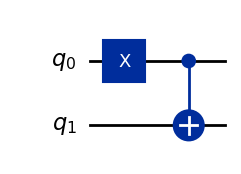

<IPython.core.display.Latex object>

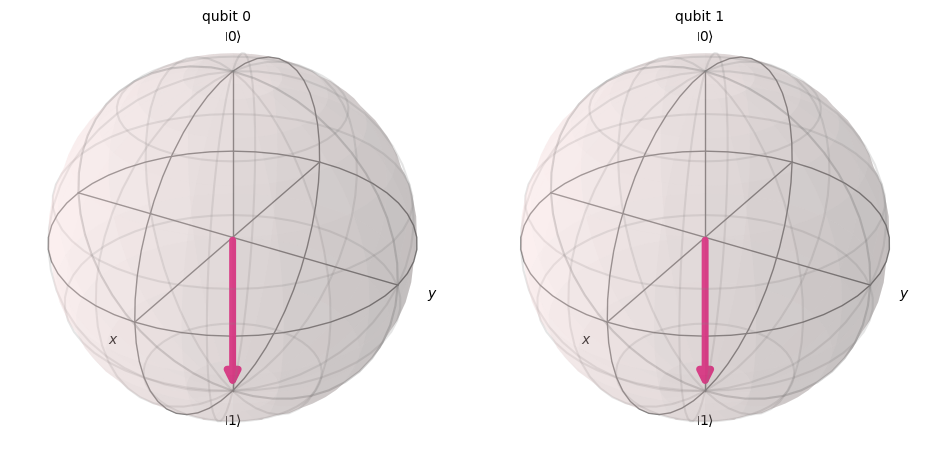

In [ ]:
circ7 = QuantumCircuit(2)   # circuito con 2 qubits

circ7.x(0)                  # ponemos el control en |1> para que la compuerta sea aplicada

circ7.cx(0, 1)              # CNOT con q0 como control y q1 como objetivo

print("Este es el caso para CNOT(0,1)|01> = |11>")

display(circ7.draw('mpl'))

op = Operator(circ7)
display(array_to_latex(op))

psi = Statevector(circ7)

print()
display(plot_bloch_multivector(psi))

Este es el caso para CNOT(1,0)|10> = |11>


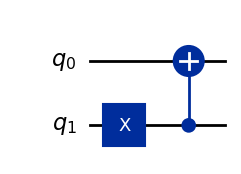

<IPython.core.display.Latex object>

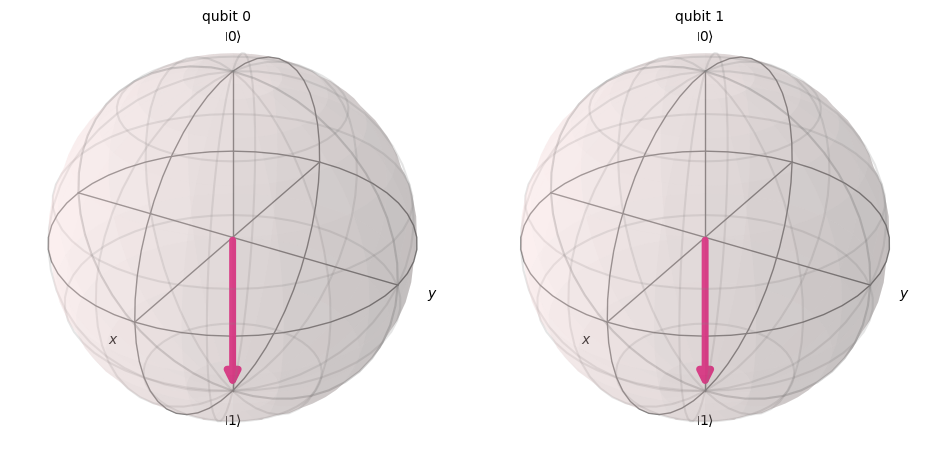

In [ ]:
circ8 = QuantumCircuit(2)   # circuito con 2 qubits

circ8.x(1)                  # ponemos el control en |1> para que la compuerta sea aplicada

circ8.cx(1, 0)              # CNOT con q1 como control y q0 como objetivo

print("Este es el caso para CNOT(1,0)|10> = |11>")

display(circ8.draw('mpl'))

op = Operator(circ8)
display(array_to_latex(op))

psi = Statevector(circ8)

print()
display(plot_bloch_multivector(psi))

### Mini actividad

Modifica el código anterior para implementar y mostrar el caso:

$$
\operatorname{CNOT}_{0,1}\ket{10}=\ket{10}.
$$

Explica que sucede.

In [ ]:
###




###

<a id="1.3.2"></a>
### 1.3.2. Compuertas controladas

Así como podemos controlar si aplicar la compuerta $X$ de acuerdo al estado de un qubit control, podemos controlar cualquier otra compuerta. Si tenemos la compuerta $U$, su versión controlada sería $CU$, y podemos decidir cuál qubit es el control y cuál es el objetivo (como para el caso de $CNOT$).

### Definición formal de una compuerta controlada

Una compuerta controlada permite aplicar una operación $U$ sobre el qubit objetivo dependiendo del estado del qubit de control. Para expresar esta operación de forma formal, podemos utilizar los proyectores sobre los estados $\ket{0}$ y $\ket{1}$:

$$
P_0=\ket{0}\bra{0}
\qquad\text{y}\qquad
P_1=\ket{1}\bra{1}.
$$

Entonces, una compuerta controlada $CU$ puede escribirse como:

$$
CU=P_0\otimes I+P_1\otimes U.
$$

Esto significa que cuando el qubit de control está en $\ket{0}$, se aplica la identidad $I$ al qubit objetivo, por lo que este permanece sin cambios. Cuando el qubit de control está en $\ket{1}$, se aplica la operación $U$ al qubit objetivo.

Para el caso particular de una compuerta $CNOT$, la operación $U$ corresponde a la compuerta $X$, por lo que:

$$
CNOT=
\ket{0}\bra{0}\otimes I+
\ket{1}\bra{1}\otimes X.
$$

Una operación unitaria en general la podemos escribir como,

$$
U=\mymatrix{rr}{
u_{11} & u_{12} \\
u_{21} & u_{22}
}
$$

Entonces su versión controlada $CU$, si el control es el qubit de la izquierda ($\ket{q_1}$), tendría las transiciones:

$$
CU_{1,0}\ket{00}=\ket{00}
$$

$$
CU_{1,0}\ket{01}=\ket{01}
$$

$$
CU_{1,0}\ket{10}
=
\ket{1}\otimes U\ket{0}
=
\ket{1}\otimes
\left(u_{11}\ket{0}+u_{21}\ket{1}\right)
$$

$$
CU_{1,0}\ket{11}
=
\ket{1}\otimes U\ket{1}
=
\ket{1}\otimes
\left(u_{12}\ket{0}+u_{22}\ket{1}\right)
$$

Su forma matricial es,

$$
CU=\mymatrix{rrrr}{
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & u_{11} & u_{12} \\
0 & 0 & u_{21} & u_{22}
}
$$

### Compuertas controladas con el control en $\ket{0}$

Por defecto, una compuerta controlada se activa cuando el qubit de control se encuentra en el estado $\ket{1}$. Sin embargo, también podemos construir una compuerta que se active cuando el qubit de control esté en $\ket{0}$.

Una forma sencilla de hacerlo es utilizar dos compuertas $X$ en el qubit de control. La primera compuerta $X$ cambia $\ket{0}$ por $\ket{1}$, permitiendo que la compuerta controlada se active. Después de aplicar la compuerta controlada, una segunda $X$ regresa el qubit de control a su estado original.

Para una compuerta $X$ controlada, el circuito puede representarse como:

$$
X_c \rightarrow CNOT \rightarrow X_c
$$

donde las compuertas $X$ se aplican únicamente al qubit de control.

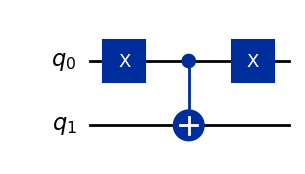

<IPython.core.display.Latex object>

In [ ]:
# Compuerta controlada activada cuando el qubit de control está en |0>

circ10 = QuantumCircuit(2)

# Cambiamos |0> -> |1> en el qubit de control
circ10.x(0)

# CNOT: se activa porque el control ahora está en |1>
circ10.cx(0, 1)

# Regresamos el qubit de control a su estado original
circ10.x(0)

display(circ10.draw('mpl'))

# Obtener y mostrar la matriz del operador
op = Operator(circ10)
display(array_to_latex(op))

En Qiskit existen varias compuertas controladas predefinidas, en el siguiente código se usarán algunas a modo de ejemplo:

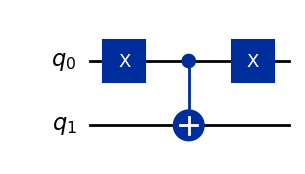

<IPython.core.display.Latex object>

In [ ]:
# Compuerta controlada activada cuando el qubit de control está en |0>

circ10 = QuantumCircuit(2)

circ10.x(0)      # Cambiamos |0> -> |1> en el qubit de control
circ10.cx(0, 1)  # Aplicamos CNOT
circ10.x(0)      # Regresamos el control a su estado original

display(circ10.draw('mpl'))

# Mostramos la matriz del operador
op = Operator(circ10)
display(array_to_latex(op))

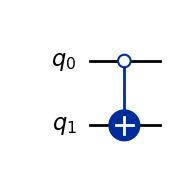

<IPython.core.display.Latex object>

In [ ]:
# Compuerta controlada activada directamente cuando el control está en |0>

circ11 = QuantumCircuit(2)

circ11.cx(0, 1, ctrl_state='0')

display(circ11.draw('mpl'))

# Mostramos la matriz del operador
op = Operator(circ11)
display(array_to_latex(op))

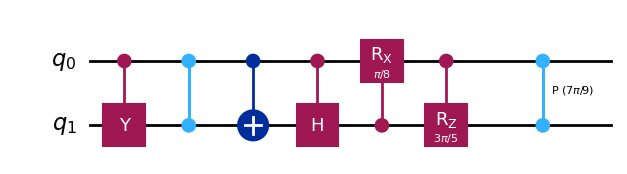

In [ ]:
circ9 = QuantumCircuit(2)    # circuito con 2 qubits

circ9.cy(0, 1)               # Y controlada, qubit control es q0, y objetivo es q1
circ9.cz(1, 0)               # Z controlada, qubit control es q1, y objetivo es q0
circ9.cx(0, 1)               # X controlada, qubit control es q0, y objetivo es q1

circ9.ch(0, 1)               # H controlada, qubit control es q0, y objetivo es q1

circ9.crx(np.pi/8, 1, 0)     # Rx controlada, ángulo de pi/8, qubit control es q1, y objetivo es q0
circ9.crz(3*np.pi/5, 0, 1)   # Rz controlada, ángulo de 3pi/5, qubit control es q0, y objetivo es q1

circ9.cp(7*np.pi/9, 1, 0)    # P controlada, ángulo de 7pi/9, qubit control es q1, y objetivo es q0

display(circ9.draw('mpl'))

En Qiskit también podemos hacer controlada una compuerta particular, en general se usa esta funcionalidad para los casos en los que la compuerta es personalizada, ya que Qiskit incluye la versión controlada de la mayoría de las compuertas de un qubit.

Creamos una compuerta personalizada con la clase `UnitaryGate`, a la que le debemos indicar la matriz que define a la operación, recordando que dicha matriz debe ser unitaria. Veamos un ejemplo:

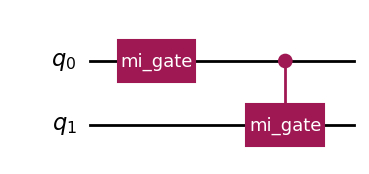

In [ ]:
from qiskit.circuit.library import UnitaryGate

matrix = [[1j, 0],
          [0 , 1,]]

mi_gate = UnitaryGate(matrix, 'mi_gate')

circ10 = QuantumCircuit(2)      # circuito con 2 qubits

circ10.append(mi_gate, [0])     # le agregamos al circuito la compuerta personalizada


mi_gate_controlada = mi_gate.control(1)   # hacemos la versión controlada de 'mi_gate', el 1 representa que solo tienes un cúbit de control.

circ10.append(mi_gate_controlada, [0, 1]) # se indican los qubits, primero el control y luego el objetivo


display(circ10.draw('mpl'))

<a id="1.3.3"></a>
### 1.3.3. Compuerta $SWAP$

Esta compuerta es la única compuerta de dos qubits que no representa una operación controlada. $SWAP$ simplemente intercambia dos qubits. Es muy útil cuando se tiene restricción física en las conexiones entre qubits.

Sus transiciones son entonces,

$$SWAP \, \ket{00}=\ket{00}$$
$$SWAP \, \ket{01}=\ket{10}$$
$$SWAP \, \ket{10}=\ket{01}$$
$$SWAP \, \ket{11}=\ket{11}$$

Su representación matricial es,

$$SWAP=\mymatrix{rrrr}{ 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 }$$

La compuerta $SWAP$ puede descomponerse como,

$$SWAP = \frac{I\otimes I+X\otimes X+Y\otimes Y+Z\otimes Z}{2}$$

En Qsikit la podemos usar con `swap()` como sigue:

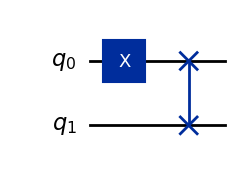

👉 Estado inicial:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>


👉 Estado después de SWAP:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>


🔵 Estado inicial:


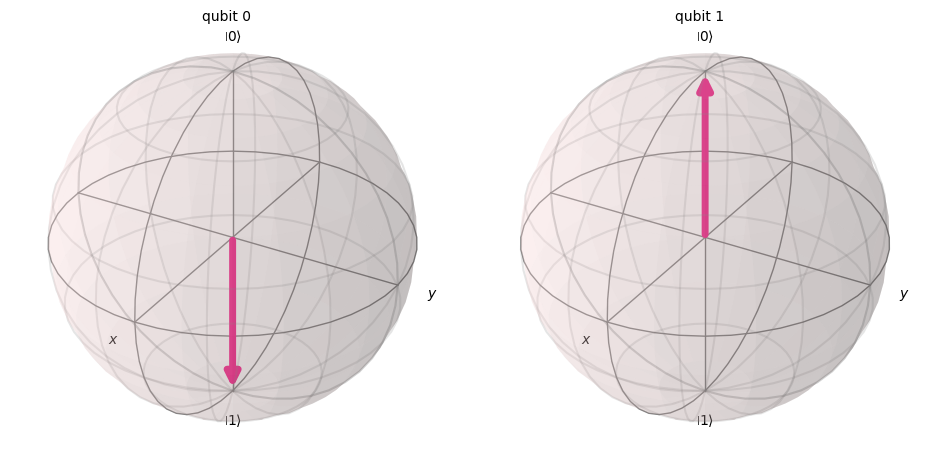

🔵 Estado después de SWAP:


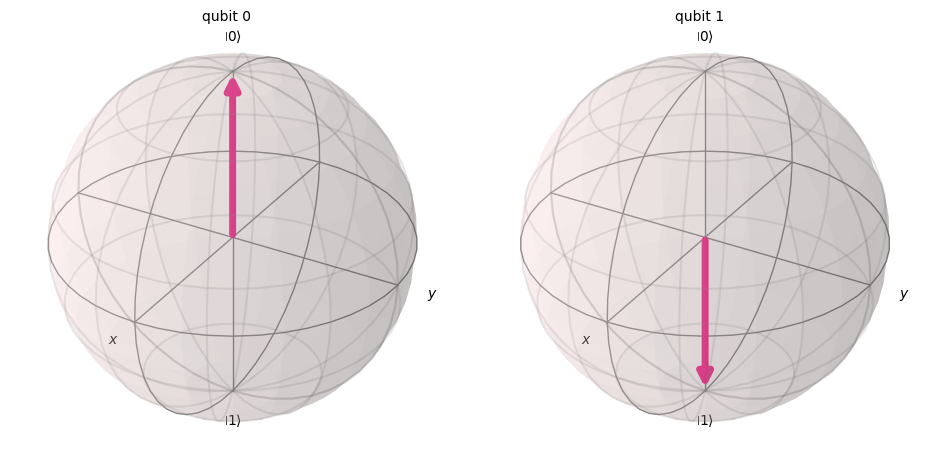

In [ ]:
circ11 = QuantumCircuit(2)    # circuito con 2 qubit

circ11.x(0)                   # obtener el estado |01>

psi_0 = Statevector(circ11)   # estado justo después de crear el circuito e iniciar el qubit en |01>

circ11.swap(0, 1)             # aplicar compuerta SWAP a los dos quibits existentes

psi_1 = Statevector(circ11)   # estado después aplicar la compuerta Z

display(circ11.draw('mpl'))   # mostrar el circuito

print("👉 Estado inicial:")
print("➤ en forma de vector:")
display(array_to_latex(psi_0))
print("➤ en forma de ket:")
display(psi_0.draw('latex'))
print()
print("👉 Estado después de SWAP:")
print("➤ en forma de vector:")
display(array_to_latex(psi_1))
print("➤ en forma de ket:")
display(psi_1.draw('latex'))

print()
print("🔵 Estado inicial:")
display(plot_bloch_multivector(psi_0))

print("🔵 Estado después de SWAP:")
display(plot_bloch_multivector(psi_1))

### Ejemplo: implementación de una compuerta controlada general

Además de las compuertas controladas que Qiskit proporciona directamente, también es posible construir una versión controlada de una operación unitaria $U$ definida por el usuario. Para ello, primero se define la matriz de la operación y posteriormente se genera su versión controlada.

Por ejemplo, consideremos la operación:

$$
U=R_y\left(\frac{\pi}{3}\right).
$$

Podemos construir su versión controlada, $CU$, haciendo que la operación $U$ se aplique al qubit objetivo únicamente cuando el qubit de control se encuentre en $\ket{1}$.

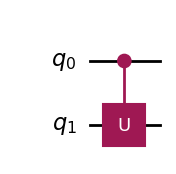

<IPython.core.display.Latex object>

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate

# Definimos una operación unitaria U = Ry(pi/3)
theta = np.pi / 3

U = np.array([
    [np.cos(theta/2), -np.sin(theta/2)],
    [np.sin(theta/2),  np.cos(theta/2)]
])

# Creamos la compuerta U
U_gate = UnitaryGate(U, label='U')

# Construimos su versión controlada
CU_gate = U_gate.control(1)

# Circuito de 2 qubits
circuit = QuantumCircuit(2)

# q0: control, q1: objetivo
circuit.append(CU_gate, [0, 1])

# Mostramos el circuito
display(circuit.draw('mpl'))

# Mostramos la matriz de la compuerta controlada
op = Operator(circuit)
display(array_to_latex(op))

En el circuito, $q_0$ funciona como qubit de control y $q_1$ como qubit objetivo. La operación $U$ solamente se aplica sobre $q_1$ cuando $q_0=\ket{1}$. Si el control está en $\ket{0}$, el estado del qubit objetivo permanece sin cambios.

La matriz resultante tiene la forma general:

$$
CU=
\begin{pmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&u_{11}&u_{12}\\
0&0&u_{21}&u_{22}
\end{pmatrix}.
$$

### Mini actividad

Modifica el código anterior para implementar y mostrar el caso:

$$
\operatorname{SWAP}\ket{10}=\ket{01}.
$$

In [ ]:
###





###

<a id="1.4"></a>
## 1.4. Compuertas de más qubits

Las compuertas pueden estar definidas para $n$ cantidad de qubits, siempre y cuando su matriz sea unitaria. Las compuertas de más de dos qubits suelen ser compuertas con más de un control.

<a id="1.4.1"></a>
### 1.4.1. Compuerta Toffoli , $CCNOT$ o $CCX$

Es una compuerta de 3 qubits. Aplicará un $NOT$ si los dos qubits de control están en el estado $\ket{1}$, en caso contrario no aplicará ninguna operación.

Su forma matricial para el caso de que los dos qubits de la izquierda sean los controles, y el de más a la derecha sea el objetivo es como sigue,

$$CCX = \mymatrix{cccccccc}{1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0}$$

Entonces sus transiciones son,

$$CCX \, \ket{000} = \ket{000}$$
$$CCX \, \ket{001} = \ket{001}$$
$$CCX \, \ket{010} = \ket{010}$$
$$CCX \, \ket{011} = \ket{011}$$
$$CCX \, \ket{100} = \ket{100}$$
$$CCX \, \ket{101} = \ket{101}$$
$$CCX \, \ket{110} = \ket{111}$$
$$CCX \, \ket{111} = \ket{110}$$

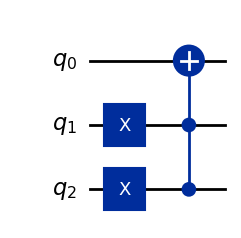

👉 Estado inicial:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>


👉 Estado después de CCX(1, 2, 0):
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>


🔵 Estado inicial:


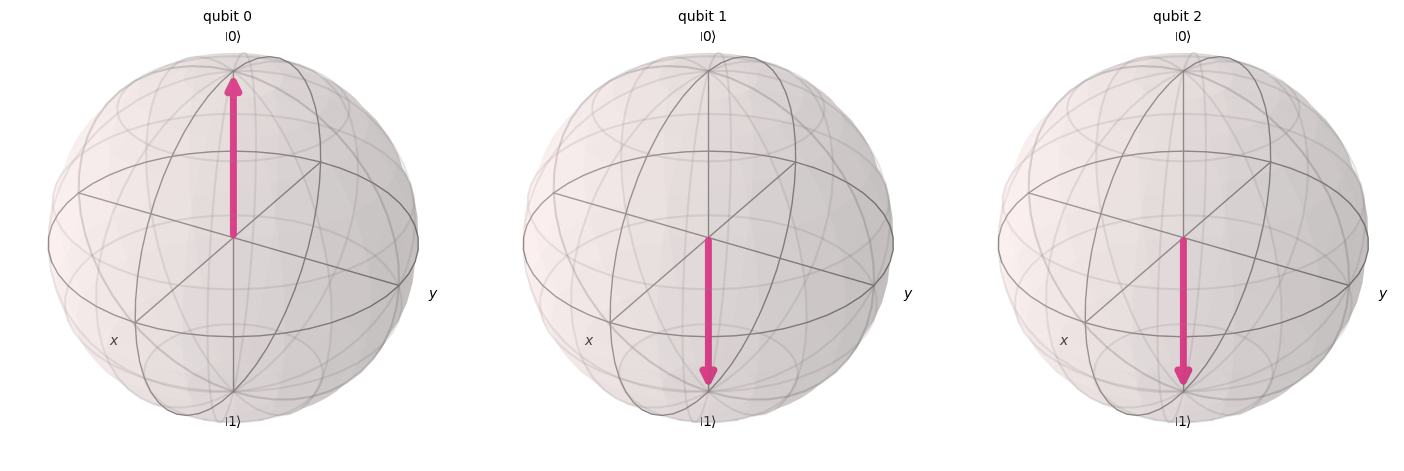

🔵 Estado después de CCX(1, 2, 0):


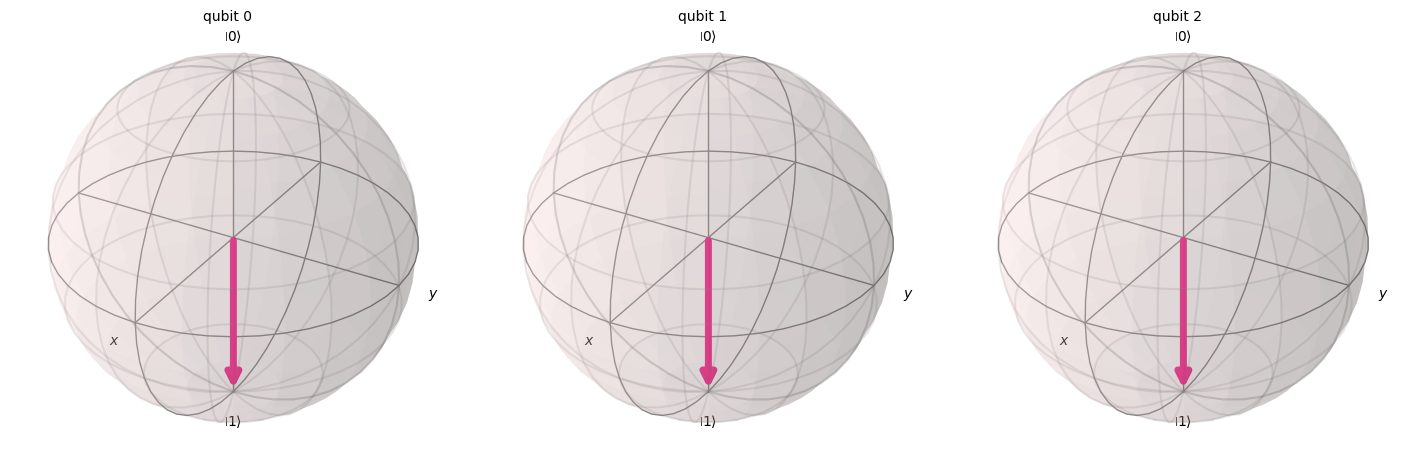

In [ ]:
circ12 = QuantumCircuit(3)    # circuito con 3 qubit

circ12.x(1)                   # obtener el estado |010>
circ12.x(2)                   # obtener el estado |110>

psi_0 = Statevector(circ12)   # estado justo después de crear el circuito e iniciar el qubit en |110>

circ12.ccx(1, 2, 0)           # aplicar compuerta CCX: control1, control2, objetivo

psi_1 = Statevector(circ12)   # estado después aplicar la compuerta Z

display(circ12.draw('mpl'))   # mostrar el circuito

print("👉 Estado inicial:")
print("➤ en forma de vector:")
display(array_to_latex(psi_0))
print("➤ en forma de ket:")
display(psi_0.draw('latex'))
print()
print("👉 Estado después de CCX(1, 2, 0):")
print("➤ en forma de vector:")
display(array_to_latex(psi_1))
print("➤ en forma de ket:")
display(psi_1.draw('latex'))

print()
print("🔵 Estado inicial:")
display(plot_bloch_multivector(psi_0))

print("🔵 Estado después de CCX(1, 2, 0):")
display(plot_bloch_multivector(psi_1))

<a id="1.4.2"></a>
### 1.4.2. Compuerta Fredkin o $CSWAP$

Esta compuerta tiene un qubit de control, y si está en el estado $\ket{1}$, entonces se efectúa un $SWAP$ a los dos quibits objetivo. La forma matricial es como sigue:

$$CSWAP = \mymatrix{cccccccc}{1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1}
$$

Entonces sus transiciones son,

$$CSWAP \ket{000} = \ket{000}$$
$$CSWAP \ket{001} = \ket{001}$$
$$CSWAP \ket{010} = \ket{010}$$
$$CSWAP \ket{011} = \ket{011}$$
$$CSWAP \ket{100} = \ket{100}$$
$$CSWAP \ket{101} = \ket{110}$$
$$CSWAP \ket{110} = \ket{101}$$
$$CSWAP \ket{111} = \ket{111}$$
    

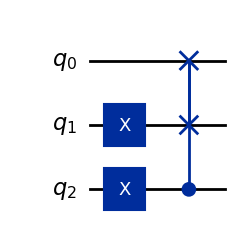

👉 Estado inicial:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>


👉 Estado después de SWAP(2, 0, 1):
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>


🔵 Estado inicial:


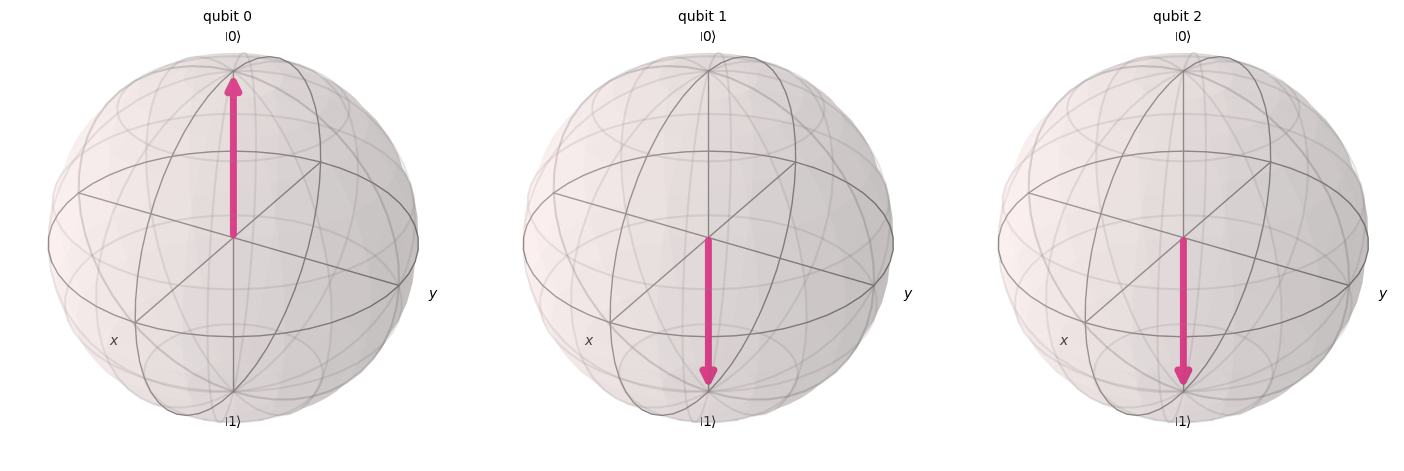

🔵 Estado después de SWAP(2, 0, 1):


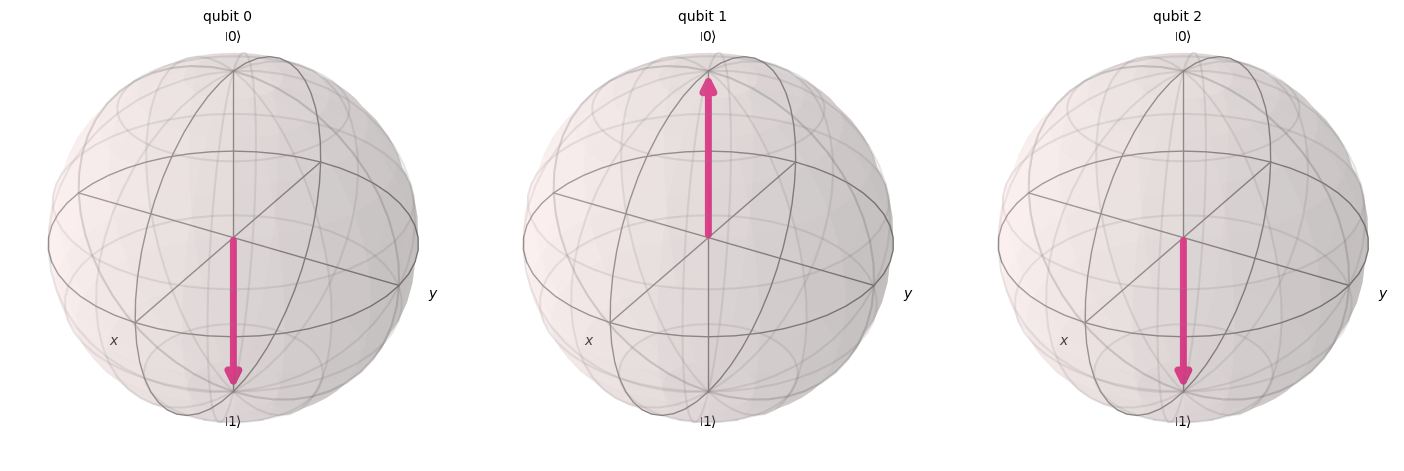

In [ ]:
circ13 = QuantumCircuit(3)    # circuito con 3 qubit

circ13.x(2)                   # obtener el estado |100>
circ13.x(1)                   # obtener el estado |110>

psi_0 = Statevector(circ13)   # estado justo después de crear el circuito e iniciar el qubit en |110>

circ13.cswap(2, 0, 1)         # aplicar compuerta CCX: control1, objetivo1, objetivo2

psi_1 = Statevector(circ13)   # estado después aplicar la compuerta Z

display(circ13.draw('mpl'))   # mostrar el circuito

print("👉 Estado inicial:")
print("➤ en forma de vector:")
display(array_to_latex(psi_0))
print("➤ en forma de ket:")
display(psi_0.draw('latex'))
print()
print("👉 Estado después de SWAP(2, 0, 1):")
print("➤ en forma de vector:")
display(array_to_latex(psi_1))
print("➤ en forma de ket:")
display(psi_1.draw('latex'))

print()
print("🔵 Estado inicial:")
display(plot_bloch_multivector(psi_0))

print("🔵 Estado después de SWAP(2, 0, 1):")
display(plot_bloch_multivector(psi_1))

<a id="1.4.3"></a>
### 1.4.3. Compuerta controlada personalizada

Compuerta personalizada en Qiskit, con dos controles y dos objetivos:

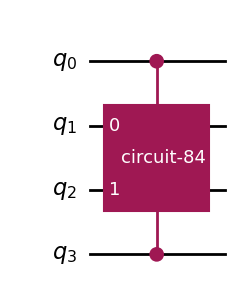

In [ ]:
# Crear una compuerta a partir de un circuito
qc1 = QuantumCircuit(2)
# estos dos qubits serán los objetivos. Definimos la compuerta.
qc1.x(0)
qc1.h(1)
custom = qc1.to_gate().control(2) # Transformamos el circuito a una nueva compuerta controlada; el 2 indica que debe ser controlada con dos qubits

# Aplicar esa compuerta a otro circuito
qc2 = QuantumCircuit(4)
qc2.append(custom, [0, 3, 1, 2]) # primeros 2 son control, el resto a los que se aplica la compuerta
qc2.draw('mpl')

<a id="2"></a>
# 2. Estados de Bell: Entrelazamiento

Existen estados particulares con su propio nombre, tal es el caso de los estados de Bell. Son relevantes porque una vez creados dichos estados, se tiene que los dos qubits que los conforman están *entrelazados*. Representan los ejemplos más simples del [entrelazamiento cuántico](https://en.wikipedia.org/wiki/Quantum_entanglement).

Que los qubits estén entralazados significa que el estado no puede ser separado en el producto tensorial de dos qubits como $\ket{a}\otimes\ket{b}$.

Conozcamos los 4 estados de Bell:

$$\ket{\Phi^+}=\frac{1}{\sqrt2}\Big(\ket{00}+\ket{11}\Big)=\frac{1}{\sqrt2}\mymatrix{r}{ 1 \\ 0 \\ 0 \\ 1 }$$

$$~~~\ket{\Phi^-}=\frac{1}{\sqrt2}\Big(\ket{00}-\ket{11}\Big)=\frac{1}{\sqrt2}\mymatrix{r}{ 1 \\ 0 \\ 0 \\ -1 }$$

$$\ket{\Psi^+}=\frac{1}{\sqrt2}\Big(\ket{01}+\ket{10}\Big)=\frac{1}{\sqrt2}\mymatrix{r}{ 0 \\ 1 \\ 1 \\ 0 }$$

$$~~~\ket{\Psi^-}=\frac{1}{\sqrt2}\Big(\ket{01}-\ket{10}\Big)=\frac{1}{\sqrt2}\mymatrix{r}{ 0 \\ 1 \\ -1 \\ 0 }$$

<div class="alert alert-block alert-info">
<strong>Ejemplo</strong>: Confirmar que el estado $\ket{\Phi^+}$ no puede ser separado como $\ket{a}\otimes\ket{b}$.

Supongamos que si se puede, entonces se debe cumplir que,
    
$$\ket{a}\otimes\ket{b}=\mymatrix{r}{ a_1 \\ a_2 }\otimes\mymatrix{r}{ b_1 \\ b_2 }=\mymatrix{r}{ a_1b_1 \\ a_1b_2 \\ a_2b_1 \\ a_2b_2 }=\mymatrix{r}{ 1 \\ 0 \\ 0 \\ 1 }$$
    
Entonces $a_1b_2=0$, lo que implica que $a_1=0$ o que $b_2=0$, si $a_1=0$ entonces no puede cumplirse que $a_1b_1=1$, y si en cambio sucede que $b_2=0$, entonces hay contradicción con $a_2b_2=1$.
    
Por lo tanto no es posible expresar el estado $\ket{\Phi^+}$ como el producto tensorial de dos qubits separados ($\ket{a}\otimes\ket{b}$).

Veamos como generar los estados de Bell en Qiskit:

La construcción del primer estado de Bell se realiza aplicando una compuerta Hadamard al primer qubit y posteriormente una compuerta CNOT:

$$
|00\rangle
\xrightarrow{H_0}
\frac{|00\rangle+|01\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
=|\Phi^{+}\rangle.
$$

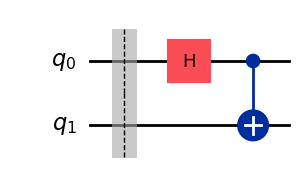

👉 Estado de Bell 1:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>

In [ ]:
circ_bell_1 = QuantumCircuit(2)    # circuito con 2 qubits

circ_bell_1.barrier()
circ_bell_1.h(0)                   # aplicar compuerta H al qubit 0
circ_bell_1.cx(0,1)                # aplicar compuerta CNOT

psi_bell_1 = Statevector(circ_bell_1)   # estado final

display(circ_bell_1.draw('mpl'))   # mostrar el circuito

print("👉 Estado de Bell 1:")
print("➤ en forma de vector:")
display(array_to_latex(psi_bell_1))
print("➤ en forma de ket:")
display(psi_bell_1.draw('latex'))

La construcción del segundo estado de Bell se realiza aplicando primero una compuerta X al qubit 0, seguida de una compuerta Hadamard y finalmente una compuerta CNOT:

$$
|00\rangle
\xrightarrow{X_0}
|01\rangle
\xrightarrow{H_0}
\frac{|00\rangle-|01\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{|00\rangle-|11\rangle}{\sqrt{2}}
=|\Phi^{-}\rangle.
$$

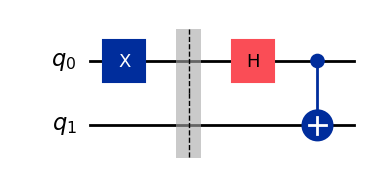

👉 Estado de Bell 2:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>

In [ ]:
circ_bell_2 = QuantumCircuit(2)    # circuito con 2 qubits

circ_bell_2.x(0)                   # aplicar compuerta X al qubit 0
circ_bell_2.barrier()
circ_bell_2.h(0)                   # aplicar compuerta H al qubit 0
circ_bell_2.cx(0,1)                # aplicar compuerta CNOT

psi_bell_2 = Statevector(circ_bell_2)   # estado final

display(circ_bell_2.draw('mpl'))   # mostrar el circuito

print("👉 Estado de Bell 2:")
print("➤ en forma de vector:")
display(array_to_latex(psi_bell_2))
print("➤ en forma de ket:")
display(psi_bell_2.draw('latex'))

La construcción del tercer estado de Bell se realiza aplicando una compuerta X al qubit 1, seguida de una compuerta Hadamard al qubit 0 y finalmente una compuerta CNOT:

$$
|00\rangle
\xrightarrow{X_1}
|10\rangle
\xrightarrow{H_0}
\frac{|10\rangle+|11\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{|01\rangle+|10\rangle}{\sqrt{2}}
=|\Psi^{+}\rangle.
$$

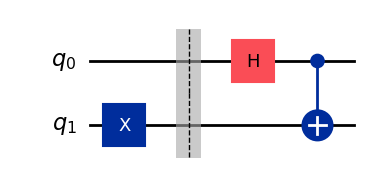

👉 Estado de Bell 2:
➤ en forma de vector:


<IPython.core.display.Latex object>

➤ en forma de ket:


<IPython.core.display.Latex object>

In [ ]:
circ_bell_3 = QuantumCircuit(2)    # circuito con 2 qubits

circ_bell_3.x(1)                   # aplicar compuerta X al qubit 1
circ_bell_3.barrier()
circ_bell_3.h(0)                   # aplicar compuerta H al qubit 0
circ_bell_3.cx(0,1)                # aplicar compuerta CNOT

psi_bell_3 = Statevector(circ_bell_3)   # estado final

display(circ_bell_3.draw('mpl'))   # mostrar el circuito

print("👉 Estado de Bell 2:")
print("➤ en forma de vector:")
display(array_to_latex(psi_bell_3))
print("➤ en forma de ket:")
display(psi_bell_3.draw('latex'))

La construcción del cuarto estado de Bell se realiza aplicando compuertas X a ambos qubits, una compuerta Z al qubit 1, seguida de una compuerta Hadamard al qubit 0 y finalmente una compuerta CNOT:

$$
|00\rangle
\xrightarrow{X_0}
|01\rangle
\xrightarrow{X_1}
|11\rangle
\xrightarrow{Z_1}
-|11\rangle
\xrightarrow{H_0}
\frac{|11\rangle-|10\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{0\rightarrow1}}
\frac{|01\rangle-|10\rangle}{\sqrt{2}}
=|\Psi^{-}\rangle.
$$

### Mini actividad

Tomando como referencia los circuitos anteriores, modifica el circuito de $\ket{\Psi^+}$ para obtener el cuarto estado de Bell:

$$
\ket{\Psi^-}
=
\frac{\ket{01}-\ket{10}}{\sqrt{2}}.
$$

Muestra el circuito y verifica el estado final en notación ket.

In [ ]:
###



###

¿Qué pasa si queremos ver un estado entrelazado usando esferas de Bloch?

In [ ]:
display(plot_bloch_multivector(psi_bell_4))

NameError: name 'psi_bell_4' is not defined

No se ven los vectores, esto debido a que los estados están entrelazados y por lo tanto no podemos tener una representación con producto tensorial de dos qubits como $\ket{a}\otimes\ket{b}$, al no existir $\ket{a}$ o $\ket{b}$, no tenemos vectores que puedan ser dibujados sobre esferas de Bloch.

<a id="4"></a>
# 3. Simular Circuitos Cuánticos

Ya sabemos crear cicuitos y manipular sus qubits. Lo que sigue es ejecutar dichos circuitos y obtener las ventajas de la parte cuántica, es decir, permitir que las probabiliadades entren en juego al momento de observar los resultados.

Hasta ahora, hemos mostrado información sobre el estado final (e intermedios) suponiendo un circuito ideal y sin forzar un colapso del resutado, hemos visto el estado como si solo efectuaramos las operaciones matemáticas, comprobando que las mismas funcionan, pero no hemos hecho nada cuántico.

Sin embargo, un experimento real termina midiendo cada qubit (normalmente sobre la base computacional $\{\ket{0}, \ket{1}\}$). Sin medición, no podemos obtener información sobre el estado. **Las mediciones hacen que el sistema cuántico colapse en bits clásicos**.

Supongamos el siguiente estado de $3$ qubits, conocido como [estado GHZ](https://en.wikipedia.org/wiki/Greenberger%E2%80%93Horne%E2%80%93Zeilinger_state),

$$\ket{\psi}=\frac{1}{\sqrt2}\Big(\ket{000}+\ket{111}\Big)$$

Denotemos la cadena de bits resultane como $abc$. Recordemos que, bajo el etiquetado de qubits utilizado por Qiskit ($\ket{q_2q_1q_0}$), $a$ correspondería al resultado en el qubit 2, $b$ al resultado en el qubit 1, y $c$ al resultado en qubit 0.

Ahora, la probabilidad de obtener un resultado $abc$ viene dada por,

$$Pr(abc)=|\braket{abc}{\psi}|^2$$

En particular para el estado GHZ, la probabilidad de obtener $000$ o $111$ es $\frac{1}{2}$.

<div class="alert alert-block alert-info">
<strong>Ejemplo</strong>: Calcular la probabilidad de medir $111$ en el estado $\ket{\psi}=\frac{1}{\sqrt2}\Big(\ket{000}+\ket{111}\Big)$.

Utilizamos la ecuación indicada para calcular la probabilidad,
    
$$\begin{aligned}
\Pr(111)&=|\braket{111}{\psi}|^2\\
&=\left|\left\langle 111\Bigg|\frac{1}{\sqrt2}\Big(\ket{000}+\ket{111}\Big)\right\rangle\right|^2\\
&=\left|\frac{1}{\sqrt2}\left\langle 111\Bigg|\Big(\ket{000}+\ket{111}\Big)\right\rangle\right|^2\\
&=\left|\frac{1}{\sqrt2}\Bigg(\left\langle 111\Big|000\right\rangle+\left\langle 111\Big|111\right\rangle\Bigg)\right|^2\\
&=\left|\frac{1}{\sqrt2}\Big(0+1\Big)\right|^2\\
&=\left|\frac{1}{\sqrt2}\right|^2\\
&=\frac{1}{2}
\end{aligned}$$


Para poder simular un circuito, es necesario indicar que qubits queremos medir y elegir en dónde queremos guardar la medición, que serán bits clásicos y necesitamos uno por cada qubit a medir.

In [ ]:
circ_ghz = QuantumCircuit(3, 3)     # circuito con 3 qubits y 3 bits clásicos

circ_ghz.h(0)                       # aplicar compuerta H al qubit 0
circ_ghz.cx(0, 1)                   # aplicar compuerta CNOT a los qubits 0 y 1
circ_ghz.cx(0, 2)                   # aplicar compuerta CNOT a los qubits 0 y 2
circ_ghz.barrier()
circ_ghz.measure([0,1,2], [0,1,2])  # medir los 3 qubits en los 3 bits clásicos

circ_ghz.draw('mpl')                # mostrar el circuito

Con la clase `BasicSimulator` podemos obtener de manera rápida y básica el resultado de la ejecución de circuitos cuánticos con pocos qubits (máximo 24); es una implementación en Python de un simulador cuántico no muy eficiente. Solo puede simular un conjunto limitado de compuertas cuánticas. Nos dara las mediciones en la base computacional.

In [ ]:
from qiskit.providers.basic_provider import BasicSimulator

simulator_basic = BasicSimulator()

In [ ]:
job = simulator_basic.run(circ_ghz, shots=1024)
result = job.result()
result

In [ ]:
counts = result.get_counts()
counts

Graficamos los resultados usando un histograma:

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts, legend=["Estado GHZ"])

Otra opción es usar la clase `StatevectorSampler` para medir los qubits en la base $Z$ (la base física en la que se miden los qubits). El `StatevectorSampler` contará el número de resultados del estado GHZ, que dependerá del número de iteraciones (shots) (experimentos realizados).

Las mediciones deben estar presentes en el circuito cuando se usa la clase `StatevectorSampler`, se usa el método `run()` para enviar los circuitos al backend.

In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()          # crear objeto de tipo StatevectorSampler

job_sampler = sampler.run([circ_ghz])   # ejecutar el circuito usando StatevectorSampler

job_sampler.result()                    # obtener las cuasi-probabilidades

In [ ]:
job_sampler.result()[0].data.c.get_counts()  # notar cómo se accede a los resultados, 'c' es el nombre del registro clásico

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram([job_sampler.result()[0].data.c.get_counts()], legend=["Estado GHZ"])

En el ejemplo anterior se dejó el valor por defecto de la cantidad de _shots_ (1024), ¿qué pasa si lo modificamos?

In [ ]:
job_sampler = sampler.run([circ_ghz], shots=256)   # ejecutar el circuito usando StatevectorSampler y especificando shots=256

plot_histogram([job_sampler.result()[0].data.c.get_counts()], legend=["Estado GHZ"])

### Recordatorio: Valores esperados

En [mecánica cuántica](https://es.wikipedia.org/wiki/Mec%C3%A1nica_cu%C3%A1ntica), el valor esperado es la esperanza matemática probabilista del resultado (medición) de un experimento. Se puede considerar como un promedio de todos los resultados posibles de una medición según lo ponderado por su probabilidad y, como tal, no es el valor más probable de una medición; de hecho el valor esperado puede "[casi seguramente](https://es.wikipedia.org/wiki/Casi_seguramente)" tener cero probabilidad de ocurrir (por ejemplo, las mediciones que solo producen valores enteros pueden tener una medición no entera). Es un concepto fundamental en todas las áreas de mecánica cuántica.

Definición:

<div class="alert alert-block alert-success">
Considera un operador $A$. El valor esperado es entonces $\langle A\rangle = \langle \psi |A|\psi \rangle$ en notación de Dirac, con $|\psi \rangle$ un vector de estado normalizado.

El valor esperado de $A$ en el estado $\ket{\psi}$ está definido como,

$$ \langle A\rangle _{\psi }=\langle \psi |A|\psi \rangle $$

Si $A$ tiene un conjunto completo de vectores propios $\phi_{j}$, con valores propios $a_{j}$, entonces la expresión anterior puede ser expresada como,

$$\langle A\rangle _{\psi }=\sum _{j}a_{j}|\langle \psi |\phi _{j}\rangle |^{2}$$


Esta expresión es similar al promedio aritmético e ilustra el significado físico del formalismo matemático: los valores propios $a_{j}$ son los posibles resultados del experimento, y su correspondiente coeficiente $|\langle \psi | \phi_j \rangle|^2$ es la probabilidad de que ocurra este resultado; a menudo se le llama probabilidad de transición.

<a id="5"></a>
# 5. Errores y cómo corregirlos

[NISQ](https://en.wikipedia.org/wiki/Noisy_intermediate-scale_quantum_era) (Noisy Intermediate-Scale Quantum) es un término acuñado por el físico [John Preskill](https://en.wikipedia.org/wiki/John_Preskill) para describir dispositivos cuánticos que cuentan con un número limitado de qubits y son susceptibles al ruido y a errores. Estos errores pueden producirse durante la preparación de los estados, la aplicación de compuertas cuánticas o el proceso de medición, afectando la precisión de los resultados obtenidos.

Debido a estas limitaciones, se han desarrollado diferentes estrategias para reducir el efecto de los errores. Entre ellas se encuentran la mitigación de errores, que busca disminuir su impacto en los resultados sin corregirlos completamente, y la corrección de errores cuánticos, que utiliza redundancia y qubits adicionales para detectar y corregir errores en la información cuántica. A continuación se presentan ambos enfoques y algunos ejemplos de su implementación.

<div align="center">
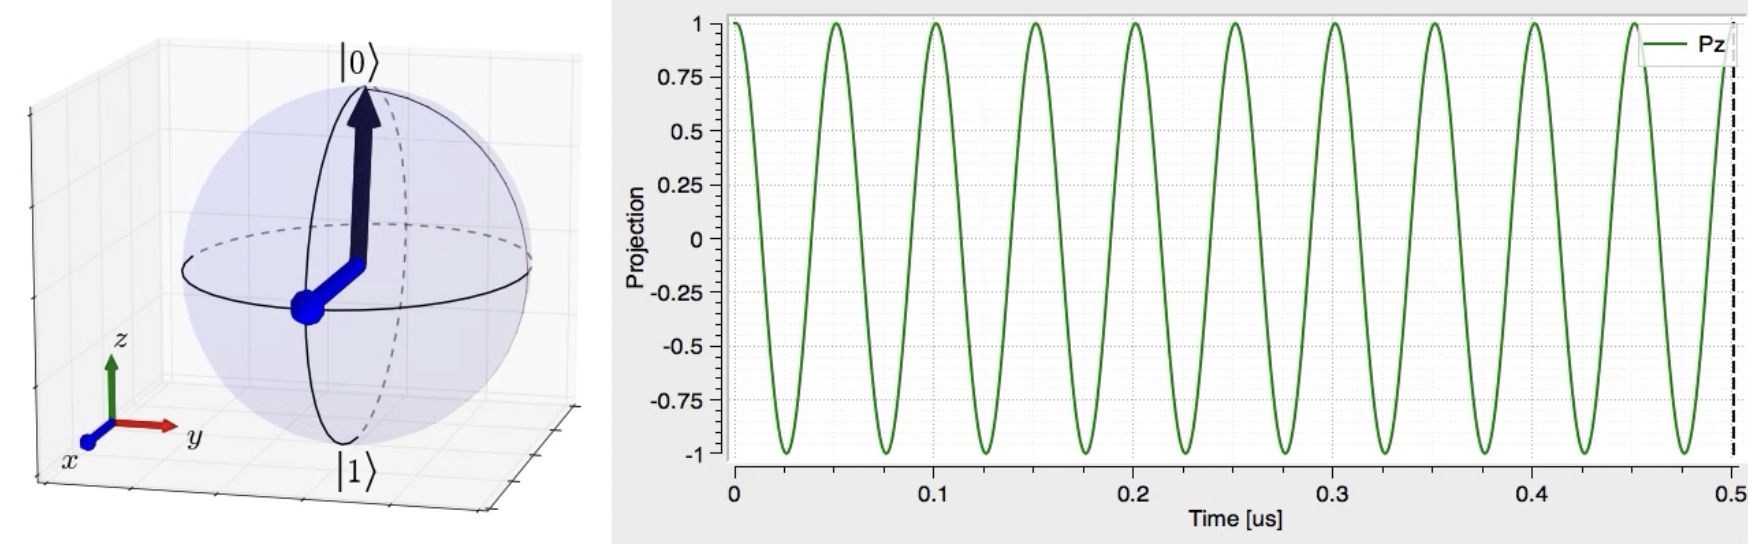

<div align="center">
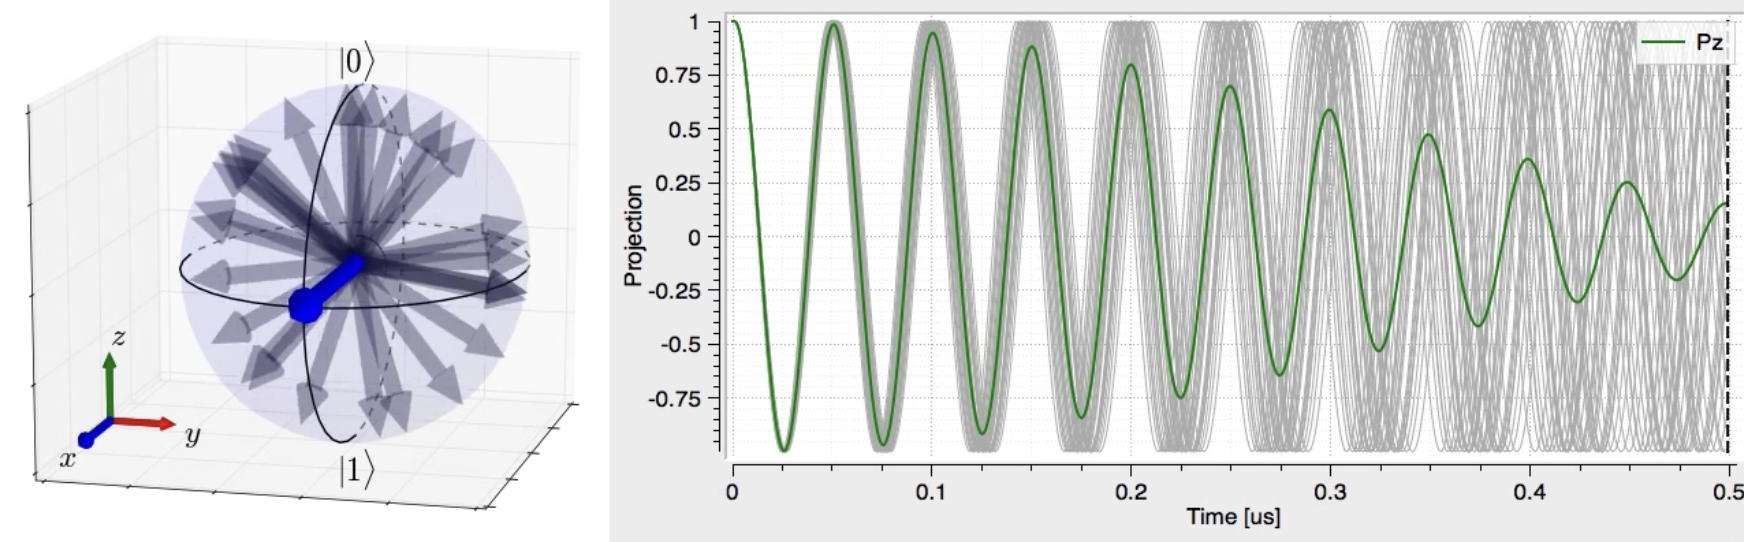

<a id="5.1"></a>
## 5.1. Mitigación de errores

La mitigación de errores es una técnica utilizada en computación cuántica para reducir el impacto de los errores sin necesidad de la redundancia de qubits o sobrecarga significativa en la computación. A diferencia de la corrección de errores, la mitigación de errores no intenta corregir los errores directamente, sino que busca minimizar su efecto en los resultados finales. Algunas de las estrategias más comunes para la mitigación de errores incluyen:

1. **Filtrado de resultados**: Se pueden aplicar filtros para eliminar mediciones que claramente han sido afectadas por errores.
2. **Extrapolación a ruido cero**: Este método implica ejecutar el mismo circuito cuántico con diferentes niveles de ruido (controlando parámetros como el tiempo de ejecución) y extrapolar los resultados a un escenario con ruido cero.
3. **Corrección basada en modelos**: Consiste en construir modelos del comportamiento del ruido en el hardware y usar estos modelos para ajustar los resultados medidos.
4. **Descomposición de operaciones**: Dividir operaciones cuánticas en sub-operaciones menos ruidosas y combinar los resultados para obtener una salida menos ruidosa.
5. **Averaging (promediado)**: Realizar múltiples ejecuciones del circuito y promediar los resultados para reducir el impacto de fluctuaciones aleatorias.

<a id="5.2"></a>
## 5.2. Corrección de errores

La corrección de errores cuánticos es un conjunto de técnicas más robusto y complejo que tiene como objetivo detectar y corregir los errores en qubits durante la computación cuántica. A diferencia de la mitigación de errores, la corrección de errores añade redundancia al sistema cuántico, utilizando múltiples qubits para proteger la información. Los principios y técnicas fundamentales incluyen:

1. **Codificación de la información**: Utilizar más de un qubit para representar un único qubit lógico. Por ejemplo, en el [código de Shor](https://errorcorrectionzoo.org/c/shor_nine), se utilizan 9 qubits físicos para representar 1 qubit lógico.
2. **Síndromes de error**: Medir síndromes de error que indican qué tipo de error ha ocurrido sin colapsar el estado cuántico. Esta información se utiliza para inferir y corregir el error.
3. **Códigos cuánticos**: Existen diversos códigos cuánticos, como el Código de Shor, el Código de Steane y los códigos CSS (Calderbank-Shor-Steane), cada uno con diferentes capacidades para detectar y corregir errores.
4. **Operaciones correctivas**: Una vez identificado el error, se aplican operaciones correctivas para devolver el qubit a su estado original.

La corrección de errores es esencial para la computación cuántica a gran escala porque los qubits son extremadamente susceptibles al ruido y a los errores operacionales. Implementar estas técnicas requiere un número significativo de qubits físicos, lo que actualmente representa un desafío debido a las limitaciones tecnológicas y la coherencia temporal de los qubits.

Para una lista más exhaustiva de algoritmos de corrección de errores (clásicos y cuánticos) visitar el [Error Correction Zoo](https://errorcorrectionzoo.org/).

<a id="5.3"></a>
## 5.3. Diferencias

- **Objetivo**: La mitigación de errores busca reducir el impacto de los errores en los resultados sin necesidad de corregirlos directamente, mientras que la corrección de errores busca identificar y corregir activamente los errores.
- **Complejidad**: La mitigación de errores suele ser menos compleja y requiere menos recursos adicionales en comparación con la corrección de errores, que implica redundancia significativa y operaciones adicionales.
- **Uso de qubits**: La mitigación de errores no necesariamente aumenta el número de qubits necesarios, mientras que la corrección de errores requiere un número mucho mayor de qubits para representar y proteger la información.

Ambas estrategias son complementarias y pueden utilizarse en conjunto para mejorar la precisión y la fiabilidad de los cálculos cuánticos.

<a id="6"></a>
# 6. Ejemplos en las SpinQ

SpinQ provee su propio framewrok de programación llamado **SpinQit**. Si se desea programar usando el framwork de spinqit se necesita hacer la siguiente instalación (se requiere otra versión de Python)

```
    pip install spinqit
```

Cabe destacar que necesita **Python 3.8** para funcionar, por lo que se recomienda crear el ambiente de conda particular

```
    conda create -n spinqit_env python=3.8
```

Comandos a ejecutar:

```
    conda create -n spinqit_env python=3.8
    conda activate spinqit_env
    pip install spinqit
    pip install jupyter
    cd 'path_con_notebooks'
    jupyer notebook
```

<a id="6.1"></a>
## 6.1. Simulación con SpinQit

#### Ejemplo 1: Cambio de estado

1 qubit</br>
Compuerta: `X`

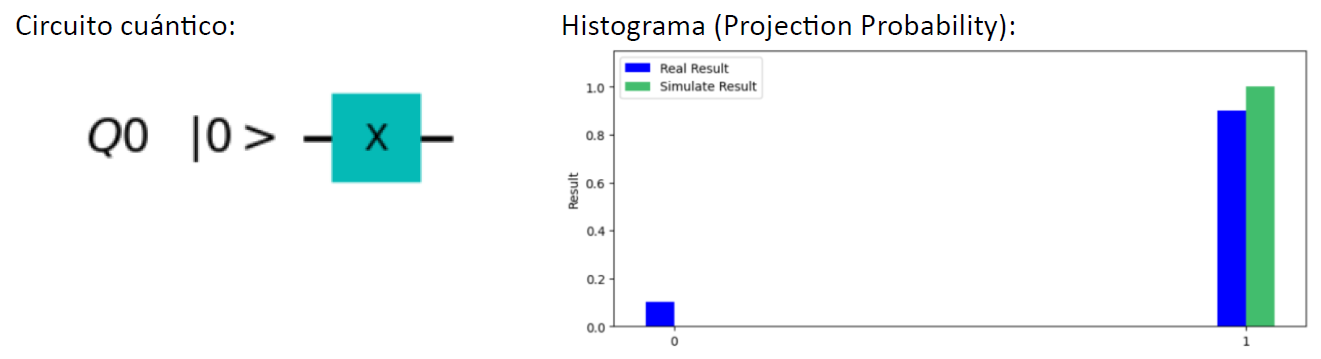

#### Ejemplo 2: Superposición con 1 qubit

1 qubit</br>
Compuerta: `H`

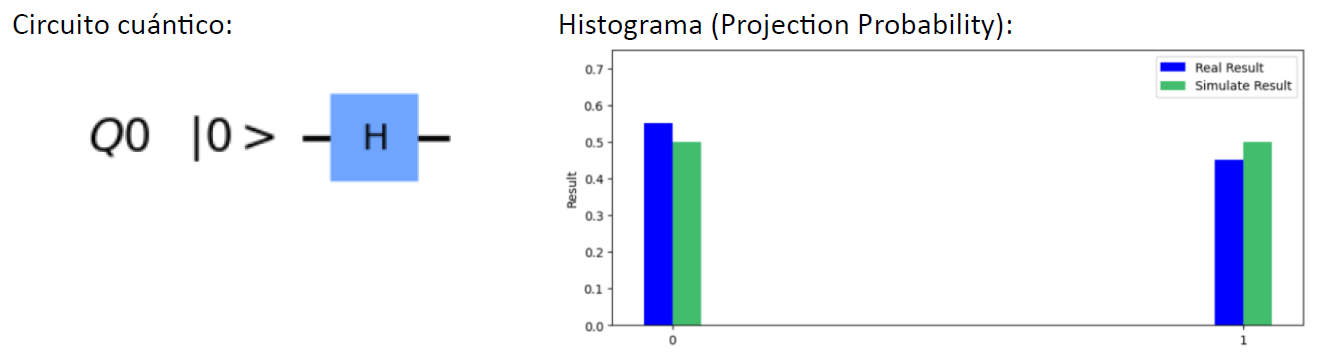

#### Ejemplo 3: Superposición con 2 qubits

2 qubits</br>
Compuertas: `H` $\otimes$ `H`

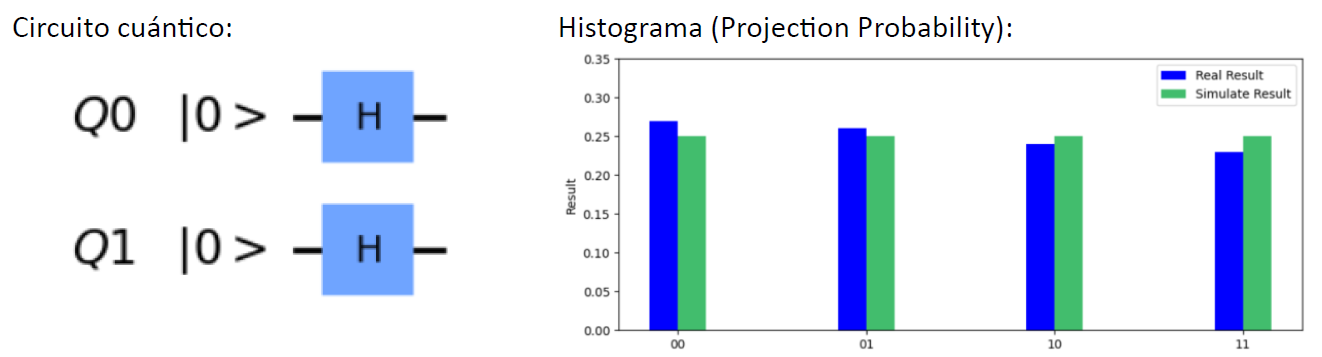

<a id="7"></a>
# 7. Práctica 2

## Instrucciones

**A)** La tarea deberá entregarse en un **Jupyter Notebook (.ipynb) nuevo**; no se permite utilizar este mismo notebook. El archivo deberá subirse a **Google Classroom**.

**B)** La tarea es **estrictamente individual**. En caso de identificar trabajos realizados en conjunto o con contenido sustancialmente compartido, la tarea será anulada para las personas involucradas.

**C)** El uso de herramientas de **inteligencia artificial** estará fuertemente penalizado y se considerará en la calificación de cada inciso de acuerdo con el grado de uso. En caso de utilizar alguna, deberá indicarse explícitamente qué herramienta fue empleada, anexar los **prompts utilizados**, señalar los incisos en los que se utilizó y explicar brevemente la razón de su uso en cada caso. El uso de inteligencia artificial sin notificación llevará a la anulación de la tarea.

**D)** Los ejercicios marcados como **opcionales** otorgarán puntos extra sobre el total de tareas. No realizarlos **no restará puntos** de la calificación obtenida.

# 1. Circuito de tres qubits

### a) Implementación del circuito y construcción de la tabla de verdad (1 punto)

Construye el circuito de 3 qubits mostrado a continuación y evalúalo con los 8 estados iniciales posibles para completar la tabla de verdad.

| $q_2$ | $q_1$ | $q_0$ | $\rightarrow$ | $q_2$ | $q_1$ | $q_0$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 0 | 0 | $\rightarrow$ | ? | ? | ? |
| 0 | 0 | 1 | $\rightarrow$ |  |  |  |
| 0 | 1 | 0 | $\rightarrow$ |  |  |  |
| 0 | 1 | 1 | $\rightarrow$ |  |  |  |
| 1 | 0 | 0 | $\rightarrow$ |  |  |  |
| 1 | 0 | 1 | $\rightarrow$ |  |  |  |
| 1 | 1 | 0 | $\rightarrow$ |  |  |  |
| 1 | 1 | 1 | $\rightarrow$ |  |  |  |

Los valores $q_2,q_1,q_0$ de la izquierda representan el estado inicial, mientras que los de la derecha representan el estado final.

Se recomienda construir primero el circuito principal y después utilizar `compose()` para combinarlo con los circuitos encargados de preparar cada estado inicial. Recuerda que las compuertas $X$ permiten cambiar el estado inicial de los qubits.

<center>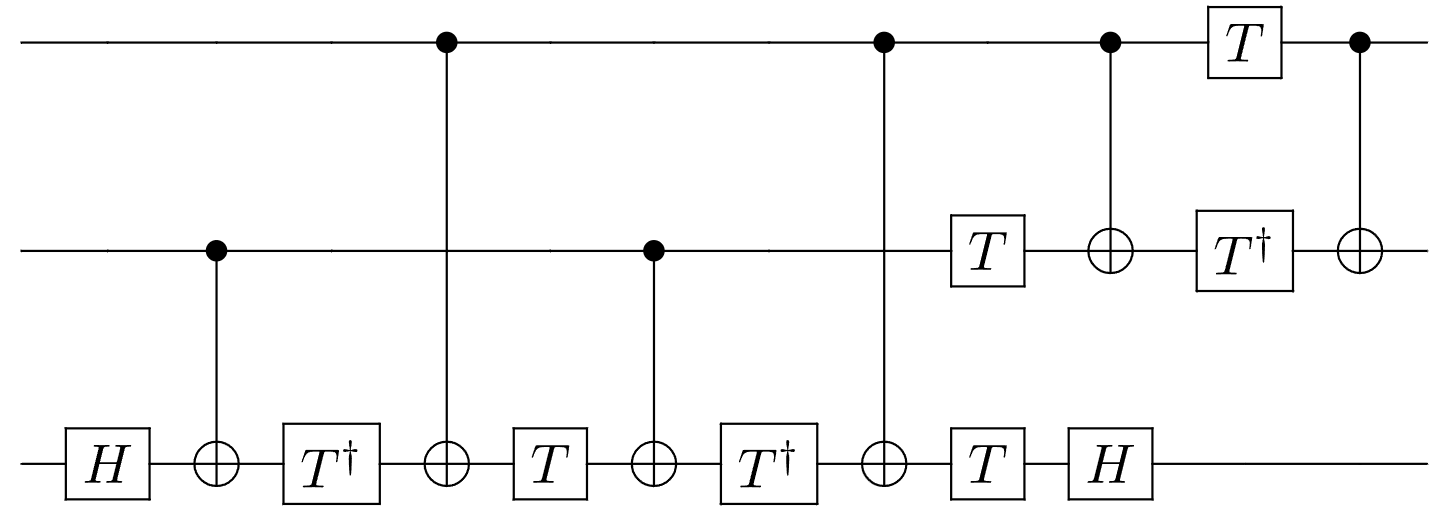

### b) Comparación de simuladores (3 puntos)

Investiga cómo ejecutar el circuito utilizando `BasicSimulator`, `StatevectorSampler` y `AerSimulator`. Selecciona dos estados iniciales de la tabla de verdad y simúlalos con los tres métodos utilizando el mismo número de *shots*.

Muestra los resultados y sus histogramas, comprueba que coincidan con la tabla de verdad y explica brevemente las diferencias entre los tres simuladores.

### c) Interpretación del circuito (1 punto)

¿Qué crees que hace este circuito? Escribe tus conclusiones en una celda de Markdown y apóyalas en los resultados de la tabla de verdad.

# 2. Circuito de cuatro qubits

### a) Implementación del circuito y construcción de la tabla de verdad (1 punto)

Construye en Qiskit el circuito de 4 qubits mostrado a continuación, respetando el orden de las compuertas e incluyendo las barreras mediante `barrier()`.

Las compuertas $X$ colocadas antes de la primera barrera preparan el estado inicial. En el circuito mostrado se utiliza el estado $\ket{0111}$, considerando el orden de Qiskit:

$$
\ket{q_3q_2q_1q_0}.
$$

Mantén $q_3$ en $\ket{0}$ y evalúa el circuito con las 8 combinaciones posibles de $q_2$, $q_1$ y $q_0$. Completa la siguiente tabla con los resultados obtenidos en los qubits medidos $q_3$ y $q_2$.

| $q_3$ | $q_2$ | $q_1$ | $q_0$ | $\rightarrow$ | $q_3$ | $q_2$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 0 | 0 | 0 | $\rightarrow$ | ? | ? |
| 0 | 0 | 0 | 1 | $\rightarrow$ |  |  |
| 0 | 0 | 1 | 0 | $\rightarrow$ |  |  |
| 0 | 0 | 1 | 1 | $\rightarrow$ |  |  |
| 0 | 1 | 0 | 0 | $\rightarrow$ |  |  |
| 0 | 1 | 0 | 1 | $\rightarrow$ |  |  |
| 0 | 1 | 1 | 0 | $\rightarrow$ |  |  |
| 0 | 1 | 1 | 1 | $\rightarrow$ |  |  |

Los valores $q_3,q_2,q_1,q_0$ de la izquierda representan el estado inicial, mientras que $q_3,q_2$ de la derecha representan los qubits medidos al final del circuito.

Se recomienda construir primero el circuito principal y después utilizar `compose()` para combinarlo con los circuitos encargados de preparar cada estado inicial.


<center>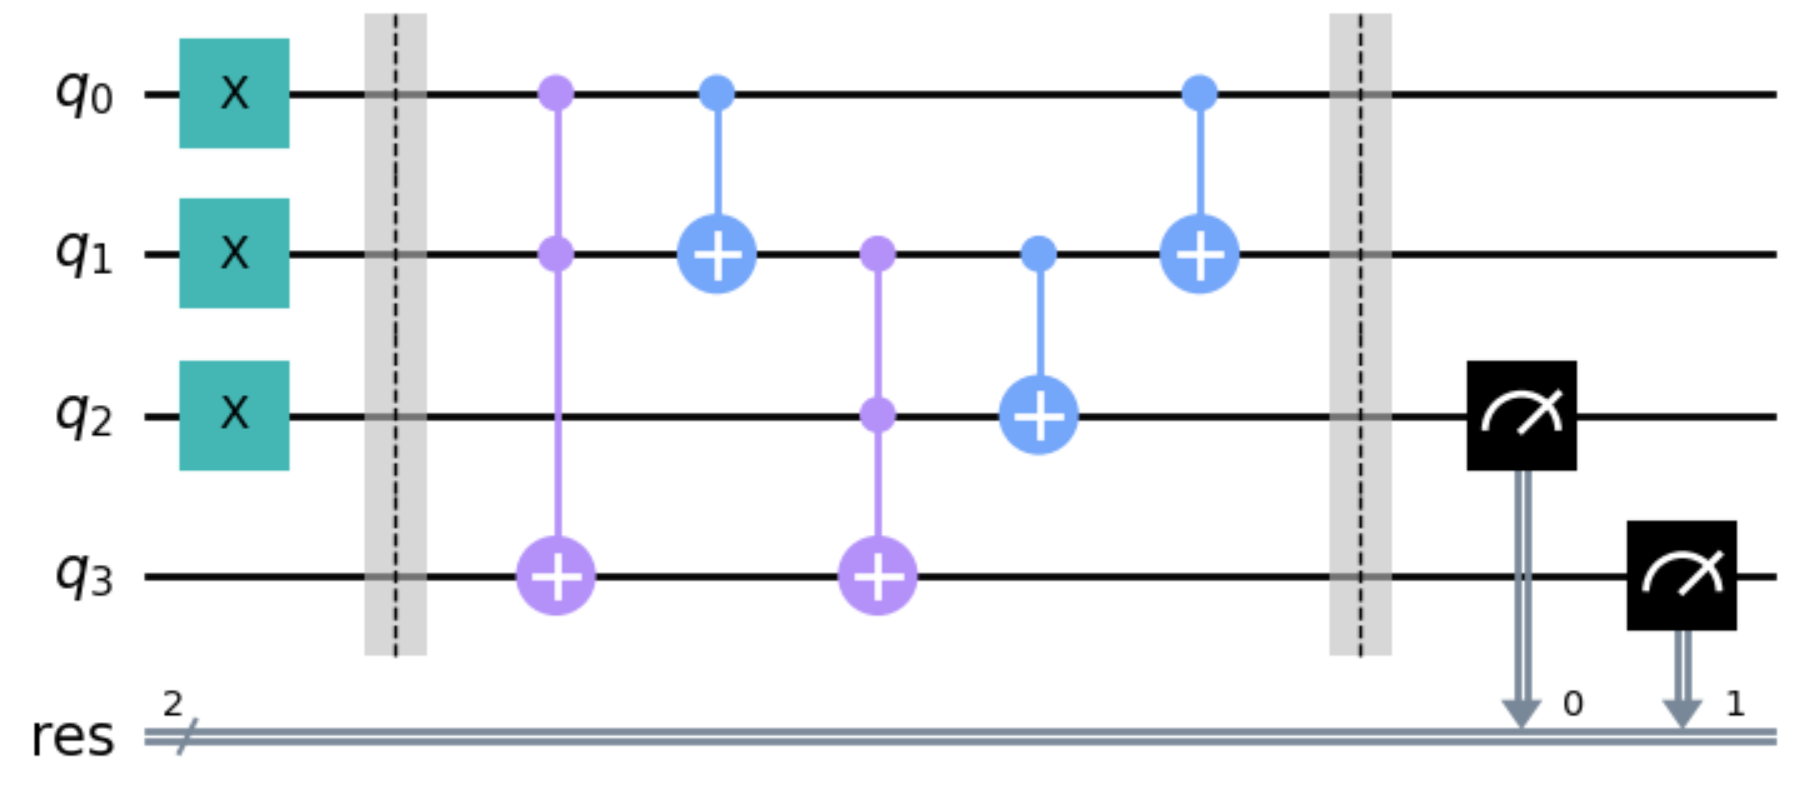

### b) Investigación del circuito (2 puntos)

Investiga qué es un **sumador completo cuántico de un bit** y explica qué relación tiene con el circuito implementado.

Describe qué función tienen sus qubits de entrada y de salida, y relaciona la información investigada con los resultados de la tabla de verdad.

Cita las fuentes consultadas; no coloques únicamente los enlaces.

### c) Efecto del número de *shots* (2 puntos)

Selecciona uno de los estados iniciales de la tabla y ejecuta el circuito con uno de los simuladores estudiados utilizando:

$$
50,\quad 100,\quad 500\quad \text{y}\quad 1000\ \textit{shots}.
$$

Utiliza el mismo estado inicial y el mismo simulador en las cuatro ejecuciones. Muestra los resultados y sus respectivos histogramas.

Compara los resultados obtenidos y explica qué efecto tiene aumentar el número de *shots*.

# 3. [Opcional] Equivalencia de la compuerta SWAP (2 puntos extra)

Implementa en PennyLane dos versiones de la compuerta SWAP. En la primera utiliza directamente `qml.SWAP(wires=[0,1])`; en la segunda utiliza únicamente tres compuertas CNOT en el siguiente orden:

$$
\mathrm{CNOT}_{0\rightarrow1},
\qquad
\mathrm{CNOT}_{1\rightarrow0},
\qquad
\mathrm{CNOT}_{0\rightarrow1}.
$$

- Muestra ambos circuitos, ejecútalos con los estados $\lvert00\rangle$, $\lvert01\rangle$, $\lvert10\rangle$ y $\lvert11\rangle$, y presenta los resultados en una tabla comparativa.

- Selecciona $\lvert01\rangle$ o $\lvert10\rangle$, describe el estado obtenido después de cada CNOT y concluye si ambas implementaciones realizan la misma operación.